# Data Preprocessing — Complete Reference

Covers every preprocessing step for both **numerical** and **text** data.

| Part | Topic |
|---|---|
| **A** | Numerical — Missing Values, Outliers, Scaling, Encoding, Feature Engineering, Selection |
| **B** | Text — Cleaning, Tokenisation, Stemming/Lemmatisation, Vectorisation, Pipelines |

In [19]:
!pip install imblearn -q

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.3f}'.format)
print('Libraries loaded ✓')

Libraries loaded ✓


---
# PART A — Numerical Data Preprocessing

## A1. Synthetic Dataset
We build a dataset with intentional problems: missing values, outliers, mixed types, and class imbalance.

In [2]:
np.random.seed(42)
n = 500

df = pd.DataFrame({
    'age':        np.random.randint(18, 70, n).astype(float),
    'income':     np.random.normal(50000, 15000, n),
    'score':      np.random.uniform(0, 100, n),
    'debt_ratio': np.random.beta(2, 5, n),
    'gender':     np.random.choice(['M', 'F', 'Other'], n, p=[0.48, 0.48, 0.04]),
    'education':  np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n,
                                   p=[0.3, 0.4, 0.2, 0.1]),
    'city':       np.random.choice(['NYC', 'LA', 'Chicago', 'Houston', 'Phoenix'], n),
    'target':     np.random.choice([0, 1], n, p=[0.85, 0.15])   # imbalanced
})

# Inject missing values
for col, frac in [('age', 0.08), ('income', 0.12), ('score', 0.05), ('gender', 0.06)]:
    idx = df.sample(frac=frac).index
    df.loc[idx, col] = np.nan

# Inject outliers
df.loc[np.random.choice(n, 10, replace=False), 'income'] *= 8
df.loc[np.random.choice(n, 5,  replace=False), 'age']    = np.random.choice([120, 150, -5], 5)

print(f'Shape: {df.shape}')
df.head()

Shape: (500, 8)


,age,income,score,debt_ratio,gender,education,city,target
0,56.000,81832.343,71.905,0.227,F,Bachelor,Phoenix,0
1,69.000,65486.979,29.712,0.453,NaN,High School,NYC,0
2,46.000,27209.451,56.640,0.600,M,Bachelor,Phoenix,0
3,NaN,42736.489,47.605,0.136,F,Bachelor,Chicago,0
4,60.000,69003.667,66.367,0.236,M,High School,Phoenix,0


## A2. Exploratory Overview

In [3]:
print('=== dtypes ===')
print(df.dtypes)
print('\n=== describe (numerical) ===')
df.describe().round(2)

=== dtypes ===
age           float64
income        float64
score         float64
debt_ratio    float64
gender            str
education         str
city              str
target          int64
dtype: object

=== describe (numerical) ===


,age,income,score,debt_ratio,target
count,461.000,440.000,475.000,500.000,500.000
mean,44.520,55508.190,51.490,0.280,0.150
std,17.180,44828.280,29.960,0.150,0.360
min,-5.000,1380.990,0.490,0.010,0.000
25%,32.000,40546.140,23.820,0.160,0.000
50%,44.000,50198.910,54.000,0.260,0.000
75%,57.000,60500.880,77.090,0.390,0.000
max,150.000,552586.610,99.940,0.750,1.000


Missing values:
        Count  Percent
income     60   12.000
age        39    7.800
gender     30    6.000
score      25    5.000


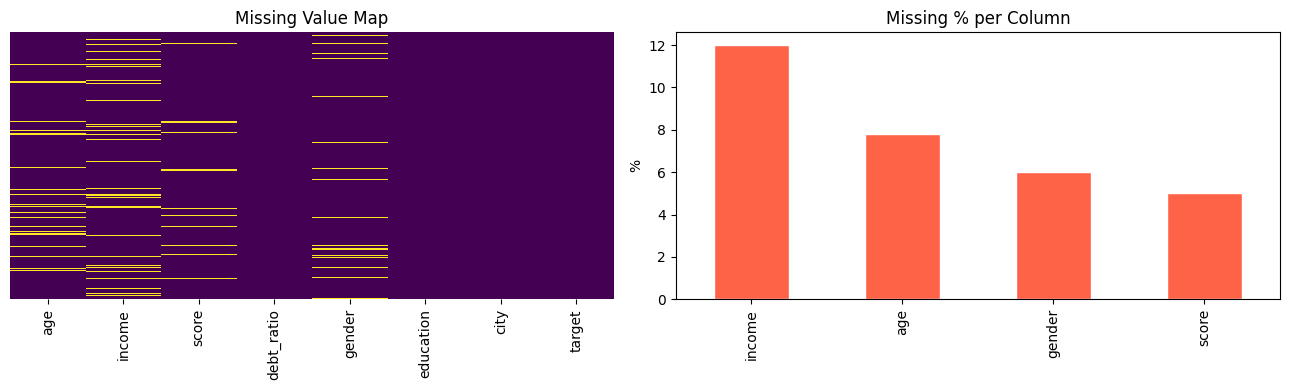

In [4]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percent', ascending=False)
print('Missing values:')
print(missing_df)

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, ax=axes[0], cmap='viridis')
axes[0].set_title('Missing Value Map')
missing_df['Percent'].plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Missing % per Column')
axes[1].set_ylabel('%')
plt.tight_layout(); plt.show()

---
## A3. Handling Missing Values

| Strategy | When to use |
|---|---|
| **Drop rows** | < 1-2% missing, data is large |
| **Drop column** | > 50-60% missing, feature not critical |
| **Mean imputation** | Numerical, roughly symmetric, no outliers |
| **Median imputation** | Numerical, skewed or has outliers |
| **Mode imputation** | Categorical |
| **KNN imputation** | Moderate missing, correlations between features |
| **Iterative (MICE)** | Complex patterns, best accuracy but slow |
| **Forward/Backward fill** | Time-series data |

In [5]:
from sklearn.experimental import enable_iterative_imputer  # must be first
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

df_work = df.copy()

# ── Mean imputation for income ─────────────────────────────────────────────
mean_imp = SimpleImputer(strategy='mean')
df_work['income_mean_imp'] = mean_imp.fit_transform(df_work[['income']])

# ── Median imputation for age ──────────────────────────────────────────────
median_imp = SimpleImputer(strategy='median')
df_work['age'] = median_imp.fit_transform(df_work[['age']])

# ── Mode imputation for gender ─────────────────────────────────────────────
df_work['gender'] = df_work['gender'].fillna(df_work['gender'].mode()[0])

# ── KNN imputation for score ───────────────────────────────────────────────
knn_imp = KNNImputer(n_neighbors=5)
num_cols = ['age', 'income', 'score', 'debt_ratio']
df_work[num_cols] = knn_imp.fit_transform(df_work[num_cols])

# ── MICE (Iterative) imputation ────────────────────────────────────────────
mice_imp = IterativeImputer(random_state=42, max_iter=10)
df_mice  = df[num_cols].copy()
df_mice_imputed = pd.DataFrame(
    mice_imp.fit_transform(df_mice), columns=num_cols
)

print('Missing after imputation:')
print(df_work[num_cols + ['gender']].isnull().sum())

Missing after imputation:
age           0
income        0
score         0
debt_ratio    0
gender        0
dtype: int64


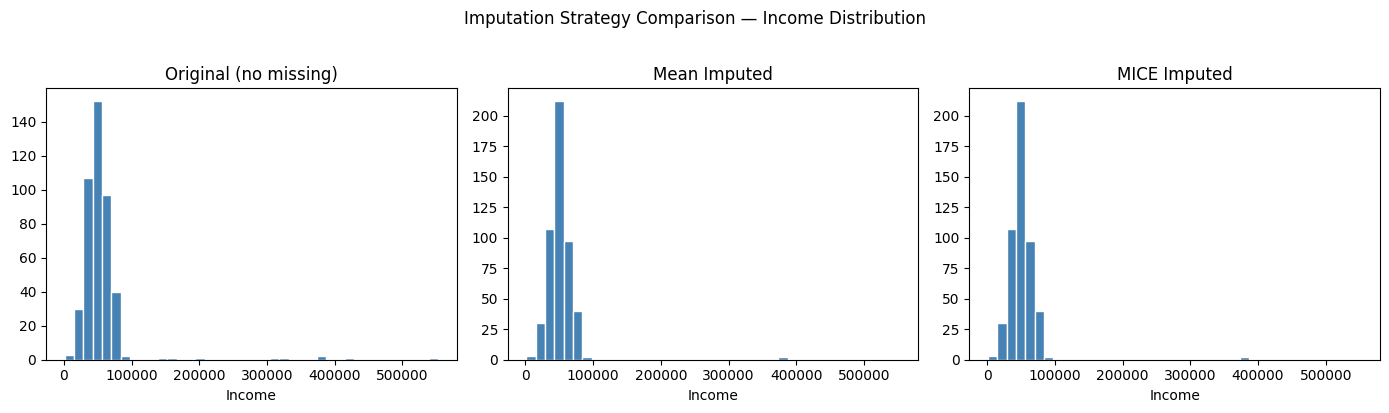

In [6]:
# Compare imputation strategies on 'income'
income_original = df['income'].dropna()
income_mean     = df_work['income_mean_imp']
income_mice     = df_mice_imputed['income']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title in zip(axes,
    [income_original, income_mean, income_mice],
    ['Original (no missing)', 'Mean Imputed', 'MICE Imputed']):
    ax.hist(data, bins=40, edgecolor='white', color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Income')
plt.suptitle('Imputation Strategy Comparison — Income Distribution', y=1.02)
plt.tight_layout(); plt.show()

---
## A4. Outlier Detection & Treatment

**Detection methods:**
- **IQR (Tukey):** Flag points below Q1−1.5·IQR or above Q3+1.5·IQR
- **Z-score:** Flag points where |z| > 3
- **Isolation Forest:** Unsupervised anomaly detection

**Treatment:**
- **Remove:** Only when you're sure they're errors
- **Winsorize (cap):** Replace with boundary value — preserves row count
- **Transform:** Log/sqrt reduces the effect of large values

In [7]:
# ── IQR method ──────────────────────────────────────────────────────────────
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

# ── Z-score method ──────────────────────────────────────────────────────────
def zscore_outliers(series, threshold=3):
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold

income_col = df_work['income']
iqr_mask, lo, hi = iqr_outliers(income_col)
zs_mask          = zscore_outliers(income_col)

print(f'IQR  outliers: {iqr_mask.sum()}  (bounds: {lo:,.0f} – {hi:,.0f})')
print(f'Z-score outliers (|z|>3): {zs_mask.sum()}')

IQR  outliers: 16  (bounds: 12,304 – 87,782)
Z-score outliers (|z|>3): 7


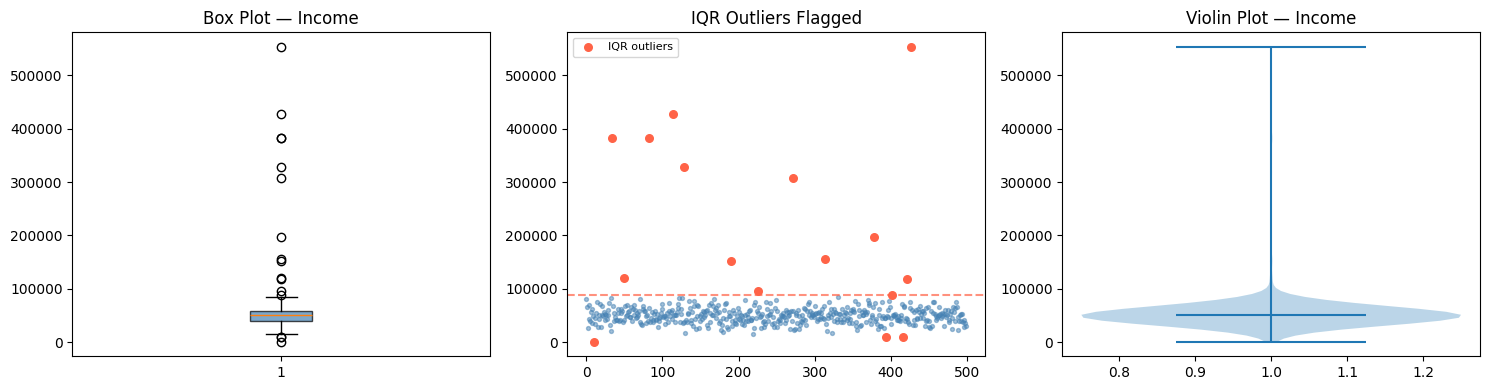

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Box plot
axes[0].boxplot(income_col, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0].set_title('Box Plot — Income')

# Scatter
axes[1].scatter(range(len(income_col)), income_col, s=8, alpha=0.5, color='steelblue')
axes[1].scatter(np.where(iqr_mask)[0], income_col[iqr_mask], s=30, color='tomato',
                label='IQR outliers')
axes[1].axhline(hi, linestyle='--', color='tomato', alpha=0.7)
axes[1].set_title('IQR Outliers Flagged')
axes[1].legend(fontsize=8)

# Violin
axes[2].violinplot(income_col, showmedians=True)
axes[2].set_title('Violin Plot — Income')

plt.tight_layout(); plt.show()

Isolation Forest flagged: 25 outliers (5.0%)


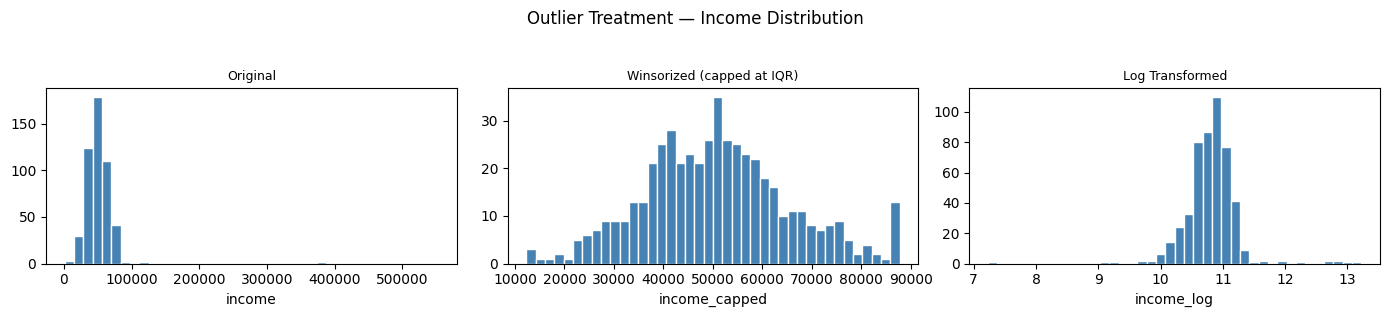

In [9]:
# ── Winsorize (cap at IQR bounds) ───────────────────────────────────────────
df_work['income_capped'] = df_work['income'].clip(lower=lo, upper=hi)

# ── Log transform ────────────────────────────────────────────────────────────
df_work['income_log'] = np.log1p(df_work['income'].clip(lower=1))

# ── Isolation Forest ────────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.05, random_state=42)
outlier_labels = iso.fit_predict(df_work[num_cols])
n_iso = (outlier_labels == -1).sum()
print(f'Isolation Forest flagged: {n_iso} outliers ({n_iso/len(df_work)*100:.1f}%)')

# Compare distributions after each treatment
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for i, (col, title) in enumerate([
    ('income',        'Original'),
    ('income_capped', 'Winsorized (capped at IQR)'),
    ('income_log',    'Log Transformed')
]):
    axes[i].hist(df_work[col], bins=40, edgecolor='white', color='steelblue')
    axes[i].set_title(title, fontsize=9)
    axes[i].set_xlabel(col)
plt.suptitle('Outlier Treatment — Income Distribution', fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

---
## A5. Feature Scaling

| Scaler | Formula | When to use |
|---|---|---|
| **StandardScaler** | $(x - \mu)/\sigma$ | Most algorithms; assumes roughly Gaussian |
| **MinMaxScaler** | $(x - x_{min})/(x_{max} - x_{min})$ | Neural networks, image data; sensitive to outliers |
| **RobustScaler** | $(x - Q_2)/(Q_3 - Q_1)$ | Data with outliers |
| **MaxAbsScaler** | $x / |x_{max}|$ | Sparse data |
| **Normalizer** | $x / \|x\|$ | Text, per-sample L2 normalisation |

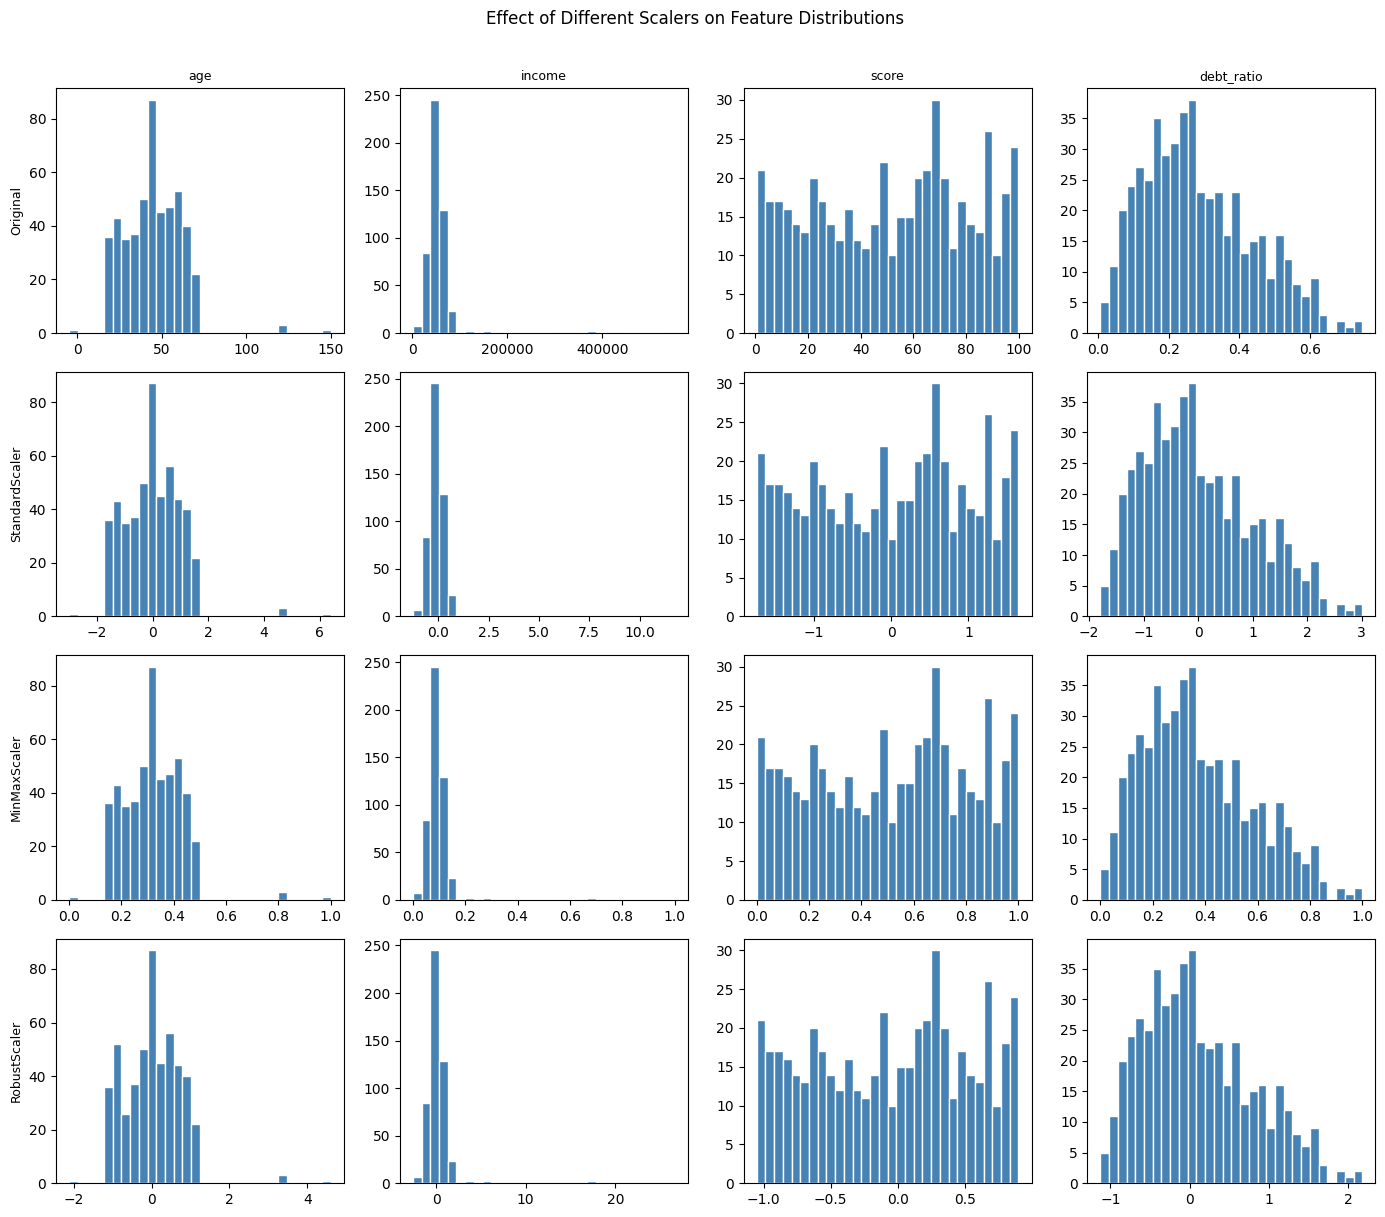

In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

num_features = df_work[['age', 'income', 'score', 'debt_ratio']].copy()

scalers = {
    'Original':      num_features,
    'StandardScaler': pd.DataFrame(StandardScaler().fit_transform(num_features),
                                   columns=num_features.columns),
    'MinMaxScaler':   pd.DataFrame(MinMaxScaler().fit_transform(num_features),
                                   columns=num_features.columns),
    'RobustScaler':   pd.DataFrame(RobustScaler().fit_transform(num_features),
                                   columns=num_features.columns),
}

fig, axes = plt.subplots(len(scalers), len(num_features.columns),
                         figsize=(14, 3 * len(scalers)))
for row, (name, scaled_df) in enumerate(scalers.items()):
    for col, feat in enumerate(num_features.columns):
        axes[row, col].hist(scaled_df[feat], bins=30, edgecolor='white', color='steelblue')
        if col == 0: axes[row, col].set_ylabel(name, fontsize=9)
        if row == 0: axes[row, col].set_title(feat, fontsize=9)

plt.suptitle('Effect of Different Scalers on Feature Distributions', y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

---
## A6. Encoding Categorical Variables

| Method | Best for | Pros / Cons |
|---|---|---|
| **Label Encoding** | Ordinal categories | Simple; implies ordinal relationship |
| **One-Hot Encoding** | Nominal, low cardinality | No ordinal assumption; creates many columns |
| **Ordinal Encoding** | Ordered categories | Preserves order; needs order specified |
| **Target Encoding** | High cardinality nominal | Compact; risk of data leakage if not done carefully |
| **Frequency Encoding** | High cardinality nominal | Simple; loses distinctiveness |
| **Binary Encoding** | High cardinality | Fewer columns than OHE |

In [11]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

df_enc = df_work[['gender', 'education', 'city', 'target']].copy()

# ── Label Encoding ────────────────────────────────────────────────────────────
le = LabelEncoder()
df_enc['gender_label'] = le.fit_transform(df_enc['gender'].astype(str))
print('Label Encoding — gender:')
print(dict(zip(le.classes_, le.transform(le.classes_))))

# ── Ordinal Encoding ──────────────────────────────────────────────────────────
edu_order = [['High School', 'Bachelor', 'Master', 'PhD']]
oe = OrdinalEncoder(categories=edu_order)
df_enc['education_ordinal'] = oe.fit_transform(df_enc[['education']])
print('\nOrdinal Encoding — education:')
print(df_enc[['education', 'education_ordinal']].drop_duplicates().sort_values('education_ordinal').to_string())

# ── One-Hot Encoding ──────────────────────────────────────────────────────────
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop first → avoid dummy trap
city_ohe = pd.DataFrame(
    ohe.fit_transform(df_enc[['city']]),
    columns=[f'city_{c}' for c in ohe.categories_[0][1:]]
)
print(f'\nOHE city columns: {city_ohe.columns.tolist()}')

# ── Target Encoding ───────────────────────────────────────────────────────────
# Mean of target per category — compute on TRAIN ONLY to avoid leakage
target_map = df_enc.groupby('city')['target'].mean()
df_enc['city_target_enc'] = df_enc['city'].map(target_map)
print('\nTarget Encoding — city:')
print(target_map.sort_values())

# ── Frequency Encoding ────────────────────────────────────────────────────────
freq_map = df_enc['city'].value_counts(normalize=True)
df_enc['city_freq_enc'] = df_enc['city'].map(freq_map)

print('\nFrequency Encoding — city:')
print(freq_map)

Label Encoding — gender:
{'F': np.int64(0), 'M': np.int64(1), 'Other': np.int64(2)}

Ordinal Encoding — education:
      education  education_ordinal
1   High School              0.000
0      Bachelor              1.000
11       Master              2.000
6           PhD              3.000

OHE city columns: ['city_Houston', 'city_LA', 'city_NYC', 'city_Phoenix']

Target Encoding — city:
city
NYC       0.102
LA        0.152
Chicago   0.159
Houston   0.160
Phoenix   0.181
Name: target, dtype: float64

Frequency Encoding — city:
city
LA        0.264
NYC       0.196
Phoenix   0.188
Houston   0.188
Chicago   0.164
Name: proportion, dtype: float64


In [12]:
# ── pd.get_dummies shortcut ───────────────────────────────────────────────────
df_dummies = pd.get_dummies(df_work[['gender','city']], drop_first=True, dtype=int)
print('pd.get_dummies output shape:', df_dummies.shape)
df_dummies.head(3)

pd.get_dummies output shape: (500, 6)


,gender_M,gender_Other,city_Houston,city_LA,city_NYC,city_Phoenix
0,0,0,0,0,0,1
1,1,0,0,0,1,0
2,1,0,0,0,0,1


---
## A7. Feature Transformation (Fixing Skewness)

Tree models are invariant to monotonic transforms — but linear models, SVM, and neural networks benefit.

| Transform | Use when |
|---|---|
| **Log (`log1p`)** | Right-skewed, strictly positive |
| **Square root** | Mild right skew, counts |
| **Box-Cox** | Positive values only; finds optimal λ |
| **Yeo-Johnson** | Works on negative values too; finds optimal λ |
| **Polynomial** | Capture non-linear relationships |

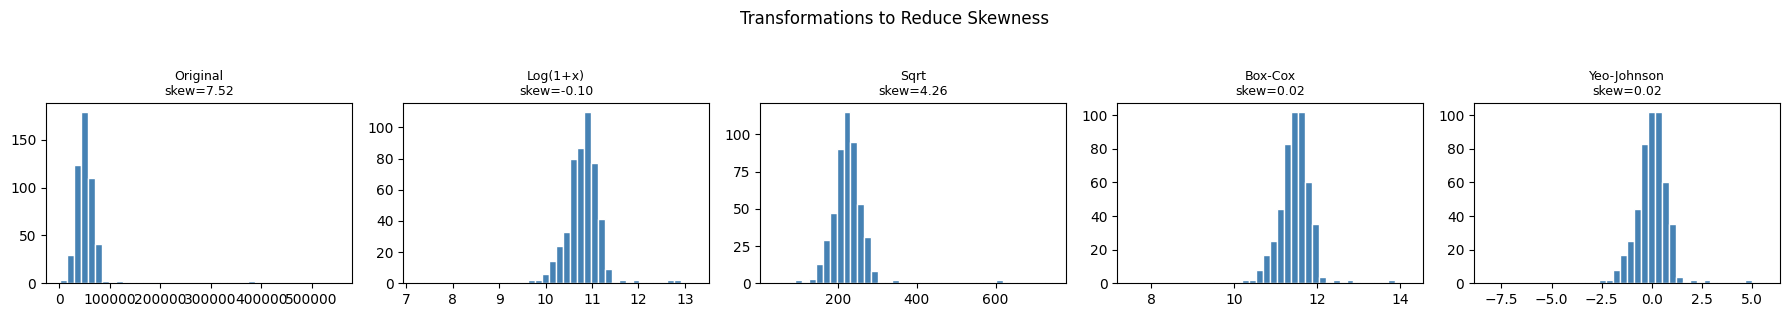

In [13]:
from sklearn.preprocessing import PowerTransformer, PolynomialFeatures
from scipy import stats

income_pos = df_work['income'].clip(lower=1)

transforms = {
    'Original':    income_pos,
    'Log(1+x)':   np.log1p(income_pos),
    'Sqrt':        np.sqrt(income_pos),
    'Box-Cox':     pd.Series(stats.boxcox(income_pos)[0]),
    'Yeo-Johnson': pd.Series(
        PowerTransformer(method='yeo-johnson')
        .fit_transform(income_pos.values.reshape(-1,1)).flatten()
    ),
}

fig, axes = plt.subplots(1, len(transforms), figsize=(18, 3))
for ax, (name, series) in zip(axes, transforms.items()):
    ax.hist(series, bins=40, edgecolor='white', color='steelblue')
    skew = pd.Series(series).skew()
    ax.set_title(f'{name}\nskew={skew:.2f}', fontsize=9)

plt.suptitle('Transformations to Reduce Skewness', fontsize=12, y=1.04)
plt.tight_layout(); plt.show()

In [14]:
# ── Polynomial Features ───────────────────────────────────────────────────────
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(num_features[['age', 'score']])
poly_names = poly.get_feature_names_out(['age', 'score'])
print(f'Original: 2 features  →  Polynomial(degree=2): {X_poly.shape[1]} features')
print('Feature names:', poly_names.tolist())

Original: 2 features  →  Polynomial(degree=2): 5 features
Feature names: ['age', 'score', 'age^2', 'age score', 'score^2']


---
## A8. Feature Selection

**Reducing dimensionality:** removes noise, reduces overfitting, speeds up training.

| Method | Type | Notes |
|---|---|---|
| **VarianceThreshold** | Filter | Remove near-constant features |
| **Correlation matrix** | Filter | Remove redundant correlated features |
| **SelectKBest** | Filter | Statistical test (chi², f-score, mutual info) |
| **RFE** | Wrapper | Recursive elimination using model coefficients |
| **Lasso (L1)** | Embedded | Coefficients shrunk to zero = implicit selection |

VarianceThreshold: 30 → 11 features


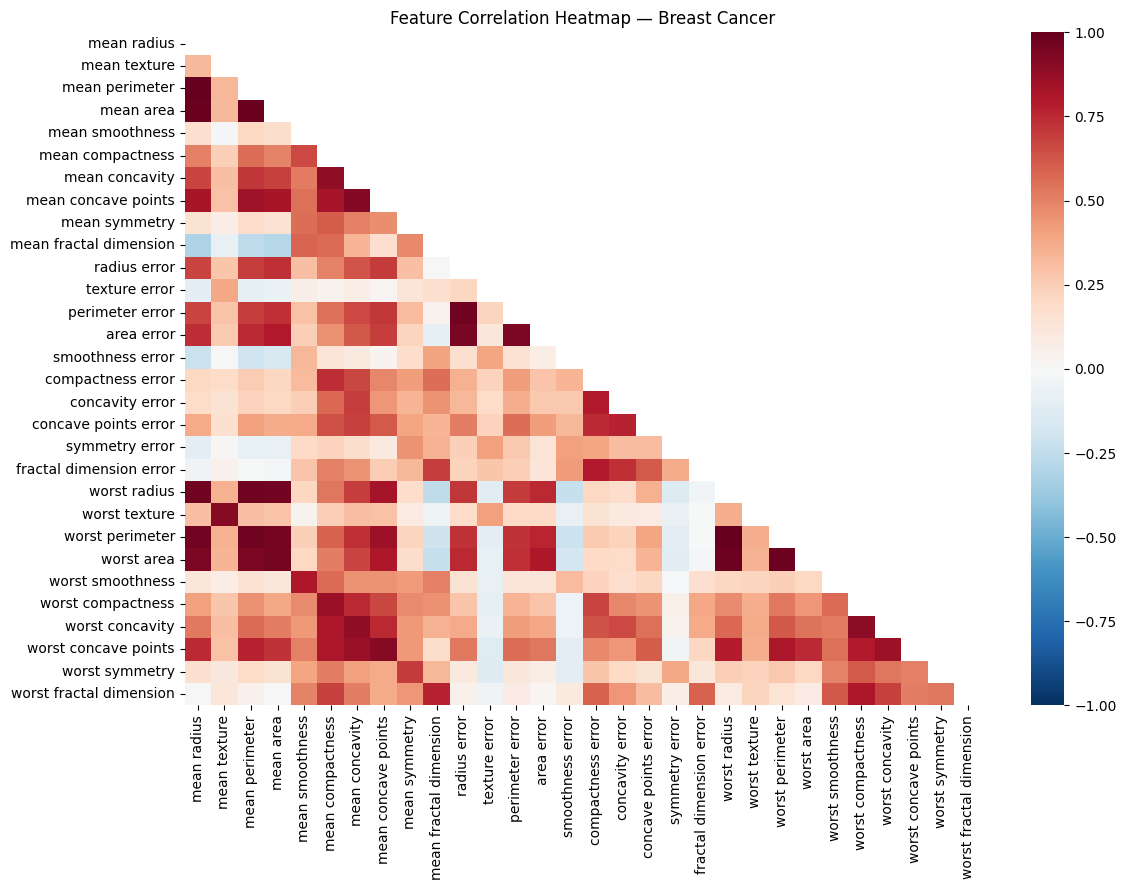


Highly correlated (>0.9) to drop: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]


In [15]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE, mutual_info_classif
from sklearn.linear_model import Lasso
from sklearn.datasets import load_breast_cancer

# Use breast cancer (30 features) for richer selection demo
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
feat_names = list(bc.feature_names)

# ── VarianceThreshold ─────────────────────────────────────────────────────────
vt = VarianceThreshold(threshold=0.1)
X_vt = vt.fit_transform(X_bc)
kept = [f for f, s in zip(feat_names, vt.get_support()) if s]
print(f'VarianceThreshold: {X_bc.shape[1]} → {X_vt.shape[1]} features')

# ── Correlation Heatmap ───────────────────────────────────────────────────────
corr = pd.DataFrame(X_bc, columns=feat_names).corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, annot=False)
ax.set_title('Feature Correlation Heatmap — Breast Cancer')
plt.tight_layout(); plt.show()

# Drop features with correlation > 0.9
upper = corr.where(mask)
to_drop = [col for col in upper.columns if any(upper[col].abs() > 0.9)]
print(f'\nHighly correlated (>0.9) to drop: {to_drop}')

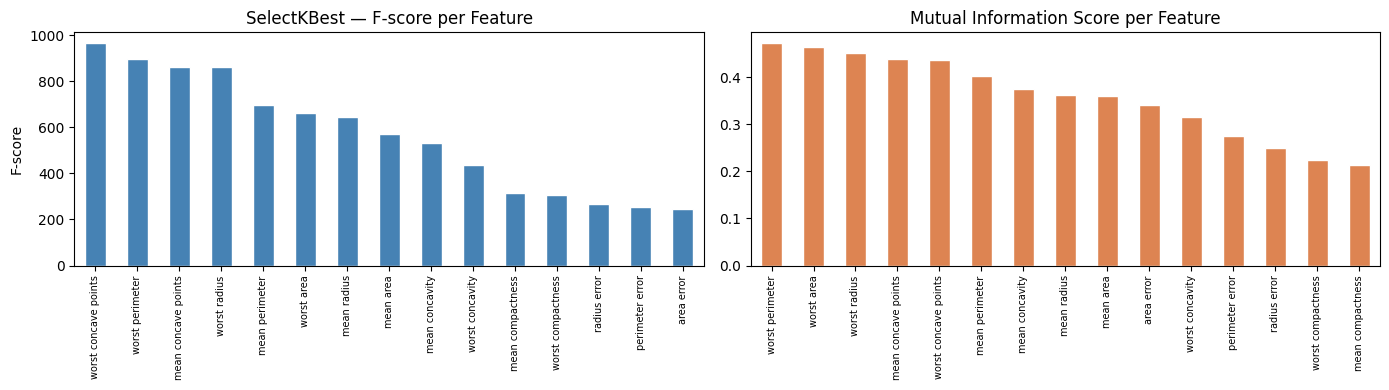

Top 5 features (F-score): [np.str_('worst concave points'), np.str_('worst perimeter'), np.str_('mean concave points'), np.str_('worst radius'), np.str_('mean perimeter')]


In [16]:
# ── SelectKBest ───────────────────────────────────────────────────────────────
selector = SelectKBest(score_func=f_classif, k=10)
X_kbest  = selector.fit_transform(X_bc, y_bc)
scores   = pd.Series(selector.scores_, index=feat_names).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
scores.head(15).plot(kind='bar', ax=ax1, color='steelblue', edgecolor='white')
ax1.set_title('SelectKBest — F-score per Feature')
ax1.set_ylabel('F-score')
ax1.tick_params(axis='x', labelsize=7)

# Mutual information
mi_scores = pd.Series(
    mutual_info_classif(X_bc, y_bc, random_state=42), index=feat_names
).sort_values(ascending=False)
mi_scores.head(15).plot(kind='bar', ax=ax2, color='#DD8452', edgecolor='white')
ax2.set_title('Mutual Information Score per Feature')
ax2.tick_params(axis='x', labelsize=7)
plt.tight_layout(); plt.show()
print(f'Top 5 features (F-score): {scores.head(5).index.tolist()}')

In [17]:
# ── RFE ──────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler as SS

X_sc_bc = SS().fit_transform(X_bc)
rfe = RFE(estimator=LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=10)
rfe.fit(X_sc_bc, y_bc)
rfe_features = [f for f, s in zip(feat_names, rfe.support_) if s]
print(f'RFE selected features: {rfe_features}')

# ── Lasso for embedded selection ──────────────────────────────────────────────
lasso = Lasso(alpha=0.01).fit(X_sc_bc, y_bc)
lasso_selected = [f for f, c in zip(feat_names, lasso.coef_) if abs(c) > 1e-6]
print(f'\nLasso selected features: {lasso_selected}')

RFE selected features: [np.str_('mean concave points'), np.str_('radius error'), np.str_('area error'), np.str_('compactness error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst concavity'), np.str_('worst concave points')]

Lasso selected features: [np.str_('mean texture'), np.str_('mean concave points'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('smoothness error'), np.str_('concavity error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst smoothness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry')]


# ── Resampling implemented from scratch (no imblearn required) ───────────────

X_imb = df_work[['age', 'income', 'score', 'debt_ratio']].values
y_imb = df_work['target'].values.astype(int)
rng   = np.random.default_rng(42)

classes, counts = np.unique(y_imb, return_counts=True)
maj_cls, min_cls = classes[np.argmax(counts)], classes[np.argmin(counts)]
n_maj, n_min     = counts.max(), counts.min()
print(f'Original: Class {maj_cls}={n_maj}  Class {min_cls}={n_min}  '
      f'(imbalance ratio {n_maj/n_min:.1f}:1)')

# ── Random Oversampling ───────────────────────────────────────────────────────
# Duplicate minority samples at random until balanced
min_idx   = np.where(y_imb == min_cls)[0]
extra_idx = rng.choice(min_idx, size=n_maj - n_min, replace=True)
X_over    = np.vstack([X_imb,          X_imb[extra_idx]])
y_over    = np.concatenate([y_imb,     y_imb[extra_idx]])
print(f'After Random Oversample : {dict(zip(*np.unique(y_over, return_counts=True)))}')

# ── Random Undersampling ──────────────────────────────────────────────────────
# Randomly drop majority samples until balanced
maj_idx   = np.where(y_imb == maj_cls)[0]
keep_maj  = rng.choice(maj_idx, size=n_min, replace=False)
keep_idx  = np.concatenate([min_idx, keep_maj])
X_under   = X_imb[keep_idx]
y_under   = y_imb[keep_idx]
print(f'After Random Undersample: {dict(zip(*np.unique(y_under, return_counts=True)))}')

# ── SMOTE (Synthetic Minority Over-sampling Technique) ────────────────────────
# For each minority sample, pick a random nearest neighbour from the minority
# class and create a synthetic point anywhere on the line between them.
#   synthetic = x_i + λ * (x_neighbour - x_i),  λ ~ Uniform(0, 1)
def smote(X, y, minority_class, k=5, random_state=42):
    rng_s     = np.random.default_rng(random_state)
    X_min     = X[y == minority_class]
    X_maj     = X[y != minority_class]
    n_needed  = len(X_maj) - len(X_min)
    synthetic = []
    for _ in range(n_needed):
        # Pick a random minority sample
        idx  = rng_s.integers(0, len(X_min))
        x_i  = X_min[idx]
        # Find k nearest minority neighbours (Euclidean)
        dists   = np.linalg.norm(X_min - x_i, axis=1)
        dists[idx] = np.inf          # exclude itself
        nn_idx  = np.argsort(dists)[:k]
        # Pick one neighbour at random, interpolate
        x_nn    = X_min[rng_s.choice(nn_idx)]
        lam     = rng_s.uniform(0, 1)
        synthetic.append(x_i + lam * (x_nn - x_i))
    X_syn = np.array(synthetic)
    y_syn = np.full(n_needed, minority_class)
    X_out = np.vstack([X, X_syn])
    y_out = np.concatenate([y, y_syn])
    return X_out, y_out

X_smote, y_smote = smote(X_imb, y_imb, minority_class=min_cls, k=5)
print(f'After SMOTE             : {dict(zip(*np.unique(y_smote, return_counts=True)))}')

# ── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, y, title in zip(axes,
    [y_imb, y_smote, y_over, y_under],
    ['Original', 'SMOTE (scratch)', 'Oversample', 'Undersample']):
    cnts = np.bincount(y.astype(int))
    ax.bar(['Class 0', 'Class 1'], cnts, color=['steelblue', 'tomato'], edgecolor='white')
    ax.set_title(f'{title}\n{cnts.tolist()}', fontsize=9)
    ax.set_ylabel('Count')
plt.suptitle('Imbalanced Data — Resampling Strategies (NumPy, no imblearn)', y=1.05)
plt.tight_layout()
plt.show()

Original class distribution: {np.int64(0): np.int64(425), np.int64(1): np.int64(75)}
After SMOTE            : {np.int64(0): np.int64(425), np.int64(1): np.int64(425)}
After RandomOverSampler: {np.int64(0): np.int64(425), np.int64(1): np.int64(425)}
After RandomUnderSampler: {np.int64(0): np.int64(75), np.int64(1): np.int64(75)}


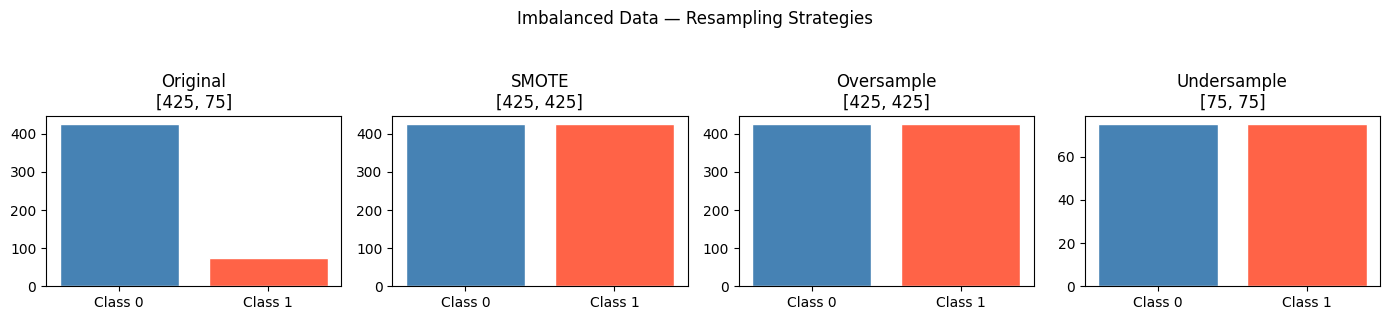

In [18]:
from imblearn.over_sampling  import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

X_imb = df_work[['age', 'income', 'score', 'debt_ratio']].values
y_imb = df_work['target'].values

print(f'Original class distribution: {dict(zip(*np.unique(y_imb, return_counts=True)))}')

# SMOTE
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_imb, y_imb)
print(f'After SMOTE            : {dict(zip(*np.unique(y_smote, return_counts=True)))}')

# Random oversampling
X_over, y_over = RandomOverSampler(random_state=42).fit_resample(X_imb, y_imb)
print(f'After RandomOverSampler: {dict(zip(*np.unique(y_over, return_counts=True)))}')

# Random undersampling
X_under, y_under = RandomUnderSampler(random_state=42).fit_resample(X_imb, y_imb)
print(f'After RandomUnderSampler: {dict(zip(*np.unique(y_under, return_counts=True)))}')

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, y, title in zip(axes,
    [y_imb, y_smote, y_over, y_under],
    ['Original', 'SMOTE', 'Oversample', 'Undersample']):
    counts = np.bincount(y.astype(int))
    ax.bar(['Class 0', 'Class 1'], counts, color=['steelblue','tomato'], edgecolor='white')
    ax.set_title(f'{title}\n{counts.tolist()}')
plt.suptitle('Imbalanced Data — Resampling Strategies', y=1.05)
plt.tight_layout(); plt.show()

---
## A10. Full Numerical Preprocessing Pipeline

Combining all steps with `sklearn.Pipeline` and `ColumnTransformer`.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose  import ColumnTransformer
from sklearn.impute   import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model  import LogisticRegression

X_raw_df = df[['age', 'income', 'score', 'debt_ratio', 'gender', 'education', 'city']]
y_raw    = df['target']

num_cols = ['age', 'income', 'score', 'debt_ratio']
cat_cols = ['gender', 'education', 'city']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(full_pipeline, X_raw_df, y_raw, cv=5, scoring='roc_auc')
print(f'5-fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('Pipeline structure:')
print(full_pipeline)

5-fold CV ROC-AUC: 0.3531 ± 0.0358
Pipeline structure:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'income', 'score',
                                                   'debt_ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                            

---
---
# PART B — Text Data Preprocessing

In [20]:
import re
import nltk
nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

from nltk.tokenize  import word_tokenize, sent_tokenize
from nltk.corpus    import stopwords
from nltk.stem      import PorterStemmer, SnowballStemmer
from nltk.stem      import WordNetLemmatizer
from nltk           import pos_tag

STOPWORDS = set(stopwords.words('english'))

# Sample corpus
corpus = [
    "I LOVED the movie! It was absolutely AMAZING :) #mustwatch https://movie.com",
    "The food wasn't good... very disappointing service. Don't go there!!! @restaurant",
    "<b>Breaking News:</b> Scientists discover new species in 2024. It's incredible!",
    "Running   fast is   better than walking slowly... or is it?? Let's see!",
    "I've been waiting for 3 hours. The customer support is non-existent. 0/10"
]

print(f'Corpus size: {len(corpus)} documents')
for i, text in enumerate(corpus):
    print(f'  [{i}] {text}')

Corpus size: 5 documents
  [0] I LOVED the movie! It was absolutely AMAZING :) #mustwatch https://movie.com
  [1] The food wasn't good... very disappointing service. Don't go there!!! @restaurant
  [2] <b>Breaking News:</b> Scientists discover new species in 2024. It's incredible!
  [3] Running   fast is   better than walking slowly... or is it?? Let's see!
  [4] I've been waiting for 3 hours. The customer support is non-existent. 0/10


---
## B1. Text Cleaning

In [21]:
def clean_text(text, steps=None):
    """
    Configurable text cleaner.
    steps: list of cleaning operations to apply (default = all)
    """
    if steps is None:
        steps = ['lower','html','urls','mentions','hashtags',
                 'contractions','punctuation','extra_spaces']

    if 'lower'        in steps: text = text.lower()
    if 'html'         in steps: text = re.sub(r'<[^>]+>', ' ', text)            # HTML tags
    if 'urls'         in steps: text = re.sub(r'http\S+|www\S+', '', text)      # URLs
    if 'mentions'     in steps: text = re.sub(r'@\w+', '', text)                # @mentions
    if 'hashtags'     in steps: text = re.sub(r'#(\w+)', r'\1', text)          # keep word, drop #
    if 'contractions' in steps:
        contractions = {"won't":"will not","can't":"cannot","n't":" not",
                        "'re":" are","'s":" is","'ll":" will","'ve":" have",
                        "'d":" would","i'm":"i am"}
        for k, v in contractions.items():
            text = text.replace(k, v)
    if 'punctuation'  in steps: text = re.sub(r'[^a-z0-9\s]', ' ', text)       # keep alphanumeric
    if 'numbers'      in steps: text = re.sub(r'\d+', '', text)
    if 'extra_spaces' in steps: text = re.sub(r'\s+', ' ', text).strip()
    return text


cleaned_corpus = [clean_text(t) for t in corpus]

print('=== BEFORE vs AFTER cleaning ===')
for orig, cleaned in zip(corpus, cleaned_corpus):
    print(f'BEFORE: {orig}')
    print(f'AFTER : {cleaned}')
    print()

=== BEFORE vs AFTER cleaning ===
BEFORE: I LOVED the movie! It was absolutely AMAZING :) #mustwatch https://movie.com
AFTER : i loved the movie it was absolutely amazing mustwatch

BEFORE: The food wasn't good... very disappointing service. Don't go there!!! @restaurant
AFTER : the food was not good very disappointing service do not go there

BEFORE: <b>Breaking News:</b> Scientists discover new species in 2024. It's incredible!
AFTER : breaking news scientists discover new species in 2024 it is incredible

BEFORE: Running   fast is   better than walking slowly... or is it?? Let's see!
AFTER : running fast is better than walking slowly or is it let is see

BEFORE: I've been waiting for 3 hours. The customer support is non-existent. 0/10
AFTER : i have been waiting for 3 hours the customer support is non existent 0 10



---
## B2. Tokenisation

In [22]:
sample = cleaned_corpus[0]

# Word tokenisation
word_tokens   = word_tokenize(sample)

# Sentence tokenisation
multi = 'I loved the movie. The acting was superb. Highly recommended.'
sent_tokens = sent_tokenize(multi)

# Simple whitespace (baseline)
ws_tokens = sample.split()

print(f'Text: "{sample}"')
print(f'\nWord tokens  ({len(word_tokens)}): {word_tokens}')
print(f'WS tokens    ({len(ws_tokens)}):   {ws_tokens}')
print(f'\nSentence tokenisation:')
for i, s in enumerate(sent_tokens):
    print(f'  [{i}] {s}')

Text: "i loved the movie it was absolutely amazing mustwatch"

Word tokens  (9): ['i', 'loved', 'the', 'movie', 'it', 'was', 'absolutely', 'amazing', 'mustwatch']
WS tokens    (9):   ['i', 'loved', 'the', 'movie', 'it', 'was', 'absolutely', 'amazing', 'mustwatch']

Sentence tokenisation:
  [0] I loved the movie.
  [1] The acting was superb.
  [2] Highly recommended.


---
## B3. Stop Word Removal

Original tokens (9):     ['i', 'loved', 'the', 'movie', 'it', 'was', 'absolutely', 'amazing', 'mustwatch']
After stop removal (5): ['loved', 'movie', 'absolutely', 'amazing', 'mustwatch']

Removed: {'it', 'the', 'i', 'was'}


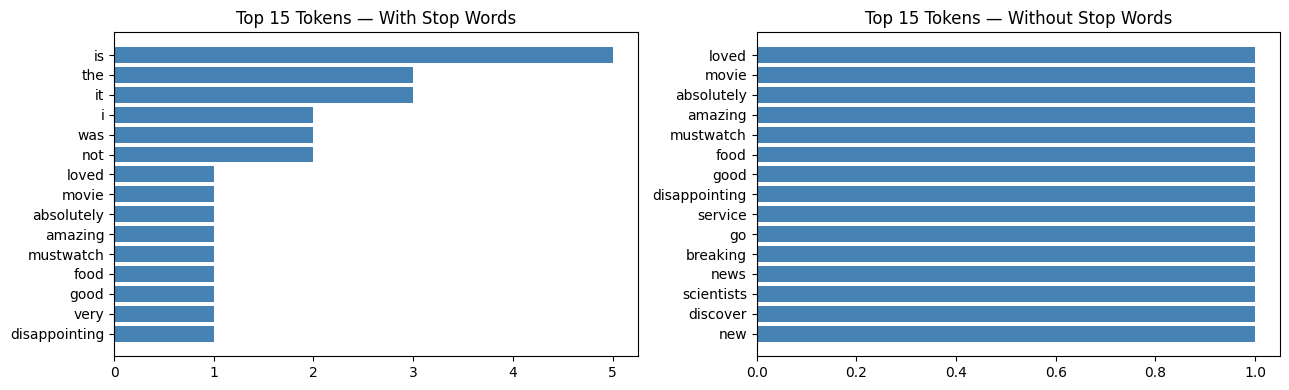

In [23]:
tokens     = word_tokenize(cleaned_corpus[0])
no_stop    = [t for t in tokens if t not in STOPWORDS and len(t) > 1]

print(f'Original tokens ({len(tokens)}):     {tokens}')
print(f'After stop removal ({len(no_stop)}): {no_stop}')
print(f'\nRemoved: {set(tokens) - set(no_stop)}')

# Visualise token frequency before/after
from collections import Counter
all_tokens    = [t for doc in cleaned_corpus for t in word_tokenize(doc)]
all_no_stop   = [t for t in all_tokens if t not in STOPWORDS and len(t) > 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for ax, tokens_list, title in zip([ax1, ax2],
    [all_tokens, all_no_stop], ['With Stop Words', 'Without Stop Words']):
    freq = Counter(tokens_list)
    words, counts = zip(*freq.most_common(15))
    ax.barh(list(reversed(words)), list(reversed(counts)), color='steelblue')
    ax.set_title(f'Top 15 Tokens — {title}')
plt.tight_layout(); plt.show()

---
## B4. Stemming vs Lemmatisation

| | Stemming | Lemmatisation |
|---|---|---|
| **Method** | Chops off suffixes by rule | Looks up dictionary base form |
| **Output** | May not be a real word | Always a valid word |
| **Speed** | Fast | Slower (needs POS tag for best results) |
| **Example** | "running" → "run", "studies" → "studi" | "running" → "run", "studies" → "study" |

In [24]:
porter   = PorterStemmer()
snowball = SnowballStemmer('english')
lemma    = WordNetLemmatizer()

test_words = ['running', 'studies', 'better', 'wolves', 'computing',
              'happily', 'flies', 'caring', 'easily', 'universities']

comparison = pd.DataFrame({
    'Original':   test_words,
    'Porter':     [porter.stem(w) for w in test_words],
    'Snowball':   [snowball.stem(w) for w in test_words],
    'Lemma(noun)':[lemma.lemmatize(w, pos='n') for w in test_words],
    'Lemma(verb)':[lemma.lemmatize(w, pos='v') for w in test_words],
})
print(comparison.to_string(index=False))

    Original  Porter Snowball Lemma(noun)  Lemma(verb)
     running     run      run     running          run
     studies   studi    studi       study        study
      better  better   better      better       better
      wolves    wolv     wolv        wolf       wolves
   computing  comput   comput   computing      compute
     happily happili  happili     happily      happily
       flies     fli      fli         fly          fly
      caring    care     care      caring         care
      easily  easili   easili      easily       easily
universities univers  univers  university universities


In [25]:
# Lemmatise with correct POS tag (best practice)
from nltk.corpus import wordnet

def get_wordnet_pos(treebank_tag):
    """Map Penn Treebank POS → WordNet POS for accurate lemmatisation."""
    if treebank_tag.startswith('J'): return wordnet.ADJ
    elif treebank_tag.startswith('V'): return wordnet.VERB
    elif treebank_tag.startswith('N'): return wordnet.NOUN
    elif treebank_tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def lemmatise_with_pos(text):
    tokens  = word_tokenize(text)
    tagged  = pos_tag(tokens)
    return [lemma.lemmatize(w, get_wordnet_pos(tag)) for w, tag in tagged]

sample = "The wolves were running fast and the studies were completed"
print('Text:', sample)
print('Lemmas (POS-aware):', lemmatise_with_pos(sample))

Text: The wolves were running fast and the studies were completed
Lemmas (POS-aware): ['The', 'wolf', 'be', 'run', 'fast', 'and', 'the', 'study', 'be', 'complete']


---
## B5. Text Vectorisation

| Method | What it captures | Dimensionality |
|---|---|---|
| **Bag of Words (CountVectorizer)** | Word presence/frequency | V (vocab size) |
| **TF-IDF** | Relative word importance | V |
| **N-grams** | Word sequences (phrases) | V^n (much larger) |
| **Binary BoW** | Word presence only | V |

In [26]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ── Bag of Words ──────────────────────────────────────────────────────────────
bow = CountVectorizer(max_features=20, stop_words='english')
X_bow = bow.fit_transform(cleaned_corpus)

bow_df = pd.DataFrame(X_bow.toarray(), columns=bow.get_feature_names_out())
print('=== Bag of Words (top 20 features) ===')
print(bow_df.to_string())

# ── Binary BoW ───────────────────────────────────────────────────────────────
binary_bow = CountVectorizer(binary=True, max_features=10, stop_words='english')
X_bin = binary_bow.fit_transform(cleaned_corpus)
print(f'\nBinary BoW — shape: {X_bin.shape}')

=== Bag of Words (top 20 features) ===
   10  existent  fast  food  good  hours  incredible  let  loved  movie  mustwatch  new  news  non  running  scientists  service  slowly  species  support
0   0         0     0     0     0      0           0    0      1      1          1    0     0    0        0           0        0       0        0        0
1   0         0     0     1     1      0           0    0      0      0          0    0     0    0        0           0        1       0        0        0
2   0         0     0     0     0      0           1    0      0      0          0    1     1    0        0           1        0       0        1        0
3   0         0     1     0     0      0           0    1      0      0          0    0     0    0        1           0        0       1        0        0
4   1         1     0     0     0      1           0    0      0      0          0    0     0    1        0           0        0       0        0        1

Binary BoW — shape: (5, 10)


=== TF-IDF matrix ===
     10  existent  fast  food  good  hours  incredible   let  loved  movie  mustwatch   new  news   non  running  scientists  service  slowly  species  support
0 0.000     0.000 0.000 0.000 0.000  0.000       0.000 0.000  0.577  0.577      0.577 0.000 0.000 0.000    0.000       0.000    0.000   0.000    0.000    0.000
1 0.000     0.000 0.000 0.577 0.577  0.000       0.000 0.000  0.000  0.000      0.000 0.000 0.000 0.000    0.000       0.000    0.577   0.000    0.000    0.000
2 0.000     0.000 0.000 0.000 0.000  0.000       0.447 0.000  0.000  0.000      0.000 0.447 0.447 0.000    0.000       0.447    0.000   0.000    0.447    0.000
3 0.000     0.000 0.500 0.000 0.000  0.000       0.000 0.500  0.000  0.000      0.000 0.000 0.000 0.000    0.500       0.000    0.000   0.500    0.000    0.000
4 0.447     0.447 0.000 0.000 0.000  0.447       0.000 0.000  0.000  0.000      0.000 0.000 0.000 0.447    0.000       0.000    0.000   0.000    0.000    0.447


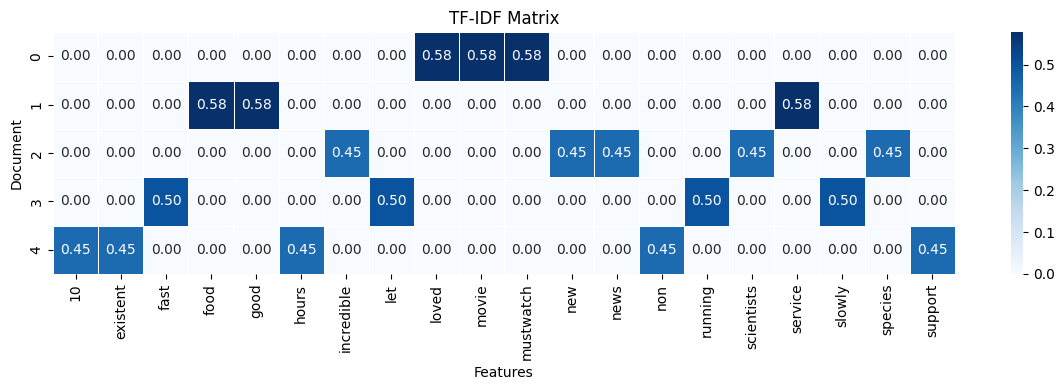

In [27]:
# ── TF-IDF ───────────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=20, stop_words='english', ngram_range=(1,1))
X_tfidf = tfidf.fit_transform(cleaned_corpus)

tfidf_df = pd.DataFrame(X_tfidf.toarray().round(3), columns=tfidf.get_feature_names_out())
print('=== TF-IDF matrix ===')
print(tfidf_df.to_string())

# Visualise TF-IDF weights
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(tfidf_df, annot=True, fmt='.2f', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_xlabel('Features'); ax.set_ylabel('Document')
ax.set_title('TF-IDF Matrix')
plt.tight_layout(); plt.show()

In [28]:
# ── N-grams ───────────────────────────────────────────────────────────────────
for ngram_range, label in [((1,1),'Unigrams'), ((2,2),'Bigrams'), ((1,2),'Uni+Bigrams')]:
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=8)
    vec.fit(cleaned_corpus)
    print(f'{label}: {sorted(vec.vocabulary_.keys())}')

Unigrams: ['10', 'non', 'running', 'scientists', 'service', 'slowly', 'species', 'support']
Bigrams: ['2024 incredible', 'news scientists', 'non existent', 'running fast', 'scientists discover', 'slowly let', 'species 2024', 'support non']
Uni+Bigrams: ['10', 'loved', 'loved movie', 'movie', 'movie absolutely', 'mustwatch', 'new', 'new species']


---
## B6. Text Feature Engineering

Hand-crafted features that capture structural properties of text.

In [29]:
def text_features(text):
    tokens     = word_tokenize(text)
    words      = [t for t in tokens if t.isalpha()]
    sents      = sent_tokenize(text)
    return {
        'char_count':       len(text),
        'word_count':       len(words),
        'sent_count':       len(sents),
        'unique_words':     len(set(words)),
        'avg_word_len':     np.mean([len(w) for w in words]) if words else 0,
        'avg_sent_len':     len(words) / len(sents) if sents else 0,
        'lexical_diversity':len(set(words)) / len(words) if words else 0,
        'stopword_count':   sum(1 for w in words if w.lower() in STOPWORDS),
        'exclamation_count':text.count('!'),
        'question_count':   text.count('?'),
        'uppercase_ratio':  sum(1 for c in text if c.isupper()) / len(text) if text else 0,
        'digit_count':      sum(1 for c in text if c.isdigit()),
    }

feat_df = pd.DataFrame([text_features(t) for t in corpus])
feat_df.index = [f'doc_{i}' for i in range(len(corpus))]
feat_df

,char_count,word_count,sent_count,unique_words,avg_word_len,avg_sent_len,lexical_diversity,stopword_count,exclamation_count,question_count,uppercase_ratio,digit_count
doc_0,76,10,2,10,5.000,5.000,1.000,4,1,0,0.184,0
doc_1,81,11,3,11,5.182,3.667,1.000,5,3,0,0.025,0
doc_2,79,10,2,10,5.500,5.000,1.000,2,1,0,0.051,4
doc_3,71,12,2,11,4.000,6.000,0.917,5,1,2,0.028,0
doc_4,73,9,3,9,4.444,3.000,1.000,5,0,0,0.027,4


---
## B7. Complete Text Preprocessing Function

In [30]:
def full_text_preprocess(text,
                         remove_stopwords=True,
                         method='lemma',       # 'lemma' | 'porter' | 'snowball' | 'none'
                         min_token_len=2):
    """
    Full text preprocessing pipeline:
    clean → tokenise → remove stops → stem/lemmatise → rejoin
    """
    # 1. Clean
    text = clean_text(text)

    # 2. Tokenise
    tokens = word_tokenize(text)

    # 3. Remove stop words & short tokens
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOPWORDS and len(t) >= min_token_len]

    # 4. Normalise
    if method == 'lemma':
        tagged  = pos_tag(tokens)
        tokens  = [lemma.lemmatize(w, get_wordnet_pos(tag)) for w, tag in tagged]
    elif method == 'porter':
        tokens  = [porter.stem(t) for t in tokens]
    elif method == 'snowball':
        tokens  = [snowball.stem(t) for t in tokens]

    return ' '.join(tokens)


print('=== Full preprocessing with lemmatisation ===')
for i, (orig, proc) in enumerate(zip(corpus, [full_text_preprocess(t) for t in corpus])):
    print(f'\n[{i}] ORIGINAL : {orig}')
    print(f'     PROCESSED: {proc}')

=== Full preprocessing with lemmatisation ===

[0] ORIGINAL : I LOVED the movie! It was absolutely AMAZING :) #mustwatch https://movie.com
     PROCESSED: love movie absolutely amazing mustwatch

[1] ORIGINAL : The food wasn't good... very disappointing service. Don't go there!!! @restaurant
     PROCESSED: food good disappointing service go

[2] ORIGINAL : <b>Breaking News:</b> Scientists discover new species in 2024. It's incredible!
     PROCESSED: break news scientist discover new specie 2024 incredible

[3] ORIGINAL : Running   fast is   better than walking slowly... or is it?? Let's see!
     PROCESSED: run fast well walk slowly let see

[4] ORIGINAL : I've been waiting for 3 hours. The customer support is non-existent. 0/10
     PROCESSED: wait hour customer support non existent 10


---
## B8. Full Text Pipeline with sklearn

In [31]:
import nltk
nltk.download('twitter_samples', quiet=True)
from nltk.corpus import twitter_samples
from sklearn.model_selection import train_test_split as tts
from sklearn.naive_bayes import MultinomialNB

pos = twitter_samples.strings('positive_tweets.json')[:500]
neg = twitter_samples.strings('negative_tweets.json')[:500]
texts_tw = pos + neg
labels_tw = [1]*len(pos) + [0]*len(neg)

X_tr_tw, X_te_tw, y_tr_tw, y_te_tw = tts(
    texts_tw, labels_tw, test_size=0.2, random_state=42, stratify=labels_tw
)

# Apply full preprocessing
X_tr_clean = [full_text_preprocess(t) for t in X_tr_tw]
X_te_clean = [full_text_preprocess(t) for t in X_te_tw]

text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,2), sublinear_tf=True)),
    ('clf',   MultinomialNB(alpha=0.5))
])

text_pipeline.fit(X_tr_clean, y_tr_tw)
acc = text_pipeline.score(X_te_clean, y_te_tw)
print(f'Tweet sentiment accuracy: {acc:.4f}')

# Test on new text
new_tweets = [
    "Absolutely love this product! Best purchase ever.",
    "Terrible experience. Never buying again. 0 stars.",
]
new_clean  = [full_text_preprocess(t) for t in new_tweets]
preds      = text_pipeline.predict(new_clean)
probs      = text_pipeline.predict_proba(new_clean)[:, 1]

for tweet, pred, prob in zip(new_tweets, preds, probs):
    label = 'Positive 😊' if pred == 1 else 'Negative 😞'
    print(f'{label} ({prob:.3f}) — {tweet}')

Tweet sentiment accuracy: 0.6600
Positive 😊 (0.766) — Absolutely love this product! Best purchase ever.
Positive 😊 (0.610) — Terrible experience. Never buying again. 0 stars.


---
## Summary Cheat Sheet

### Numerical

| Problem | Recommended approach |
|---|---|
| Missing < 5% | Median/Mode imputation |
| Missing 5–30% | KNN or MICE imputation |
| Missing > 50% | Drop column (or flag + impute) |
| Outliers, no errors | RobustScaler or Winsorize |
| Right-skewed positive | Log transform or Yeo-Johnson |
| Nominal, low cardinality | One-Hot Encoding |
| Nominal, high cardinality | Target or Frequency Encoding |
| Ordered categories | Ordinal Encoding |
| Imbalanced classes | SMOTE + class_weight='balanced' |
| Many features | Correlation filter + RFE or Lasso |

### Text

| Step | Tool |
|---|---|
| Remove HTML, URLs, mentions | `re.sub` |
| Lowercase | `str.lower()` |
| Expand contractions | Dictionary lookup |
| Tokenise | `nltk.word_tokenize` |
| Remove stop words | `nltk.corpus.stopwords` |
| Lemmatise (best quality) | `WordNetLemmatizer` + POS tag |
| Stem (fast) | `PorterStemmer` / `SnowballStemmer` |
| Vectorise | `TfidfVectorizer(ngram_range=(1,2))` |
| Full pipeline | `Pipeline([tfidf, model])` |